# **1. Import Libraries**

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

path = "https://drive.google.com/drive/folders/1jIGaIrj8UpQjF2kNQ-y8RMlMM94Inffs"

for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files)

# **2. Dataset Path**

In [4]:
DATASET_PATH = r'/content/drive/MyDrive/vehicle_data'

In [5]:
import os

# List contents of your Google Drive's MyDrive folder
print(os.listdir('/content/drive/MyDrive'))


['Colab Notebooks', 'vehicle_data', 'DIVYA SINGH', 'EXPERT PYTHON.ipynb', 'AADHAR CARD.jpg', 'NEURAL_NETWORKS_DIVYA_SINGH.ipynb', 'DIVYA SINGH NLP_Sem_3.ipynb', 'Cloud Technology.docx', 'Divya CV.pdf']


# **3. Load Images using OpenCV**

In [6]:
IMG_SIZE = 128

categories = os.listdir(DATASET_PATH)
print("Classes:", categories)

data = []
labels = []

for label, category in enumerate(categories):
    folder_path = os.path.join(DATASET_PATH, category)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            # Read image
            img = cv2.imread(img_path)

            # Resize
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Convert BGR → RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Normalize
            img = img / 255.0

            data.append(img)
            labels.append(label)

        except:
            pass

X = np.array(data)
y = np.array(labels)

Classes: ['rickshaw', 'skateboard', 'scooter', 'kayak', 'van - Copy', 'fire_truck', 'tractor', 'hovercraft', 'unicycle', 'truck', 'boat', 'segway', 'helicopter', 'jet_ski', 'car', 'bus', 'motorcycle', 'van', 'ambulance', 'bicycle', 'airplane']


# **4. Train / Validation / Test Split**

In [7]:
# First split (train + temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second split (validation + test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# **5. One-Hot Encoding**

In [8]:
num_classes = len(categories)

y_train = to_categorical(y_train, num_classes)
y_val = to_categorical(y_val, num_classes)
y_test = to_categorical(y_test, num_classes)

# **6. CNN Model**

In [9]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │         5,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,521,429 (24.88 MB)

 Trainable params: 6,521,429 (24.88 MB)

 Non-trainable params: 0 (0.00 B)

# **7. Train Model**

In [10]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.0654 - loss: 3.0327 - val_accuracy: 0.1166 - val_loss: 2.9053
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.1449 - loss: 2.8265 - val_accuracy: 0.2213 - val_loss: 2.6257
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.2294 - loss: 2.5227 - val_accuracy: 0.2659 - val_loss: 2.4043
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.3254 - loss: 2.1936 - val_accuracy: 0.2950 - val_loss: 2.2798
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.4062 - loss: 1.8796 - val_accuracy: 0.3293 - val_loss: 2.2138
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.5129 - loss: 1.5201 - val_accuracy: 0.3208 - val_loss: 2.2907
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6048 - loss: 1.2288 - val_accuracy: 0.3413 - val_loss: 2.3229
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.6721 - loss: 1.0000 - val_accuracy: 0.3482 - v

# **8. Evaluate Model**

In [12]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 374ms/step - accuracy: 0.3756 - loss: 2.5636
Test Accuracy: 0.37564322352409363
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 254ms/step


# **9. Confusion Matrix**

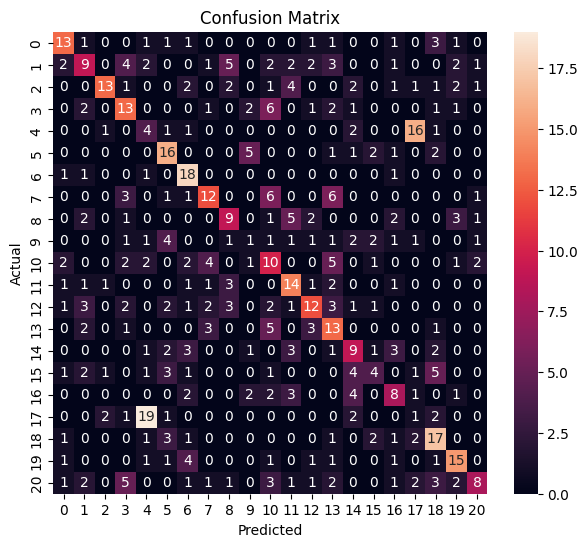

In [13]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **10. Precision & Recall**

In [14]:
print(classification_report(y_true, y_pred_classes, target_names=categories))

              precision    recall  f1-score   support

    rickshaw       0.54      0.54      0.54        24
  skateboard       0.36      0.25      0.30        36
     scooter       0.72      0.42      0.53        31
       kayak       0.38      0.43      0.41        30
  van - Copy       0.12      0.15      0.13        26
  fire_truck       0.46      0.57      0.51        28
     tractor       0.46      0.82      0.59        22
  hovercraft       0.48      0.40      0.44        30
    unicycle       0.38      0.35      0.36        26
       truck       0.08      0.05      0.06        19
        boat       0.24      0.31      0.27        32
      segway       0.41      0.54      0.47        26
  helicopter       0.48      0.35      0.41        34
     jet_ski       0.31      0.46      0.37        28
         car       0.32      0.35      0.33        26
         bus       0.31      0.17      0.22        24
  motorcycle       0.35      0.35      0.35        23
         van       0.04    

# **11. Display Predictions**

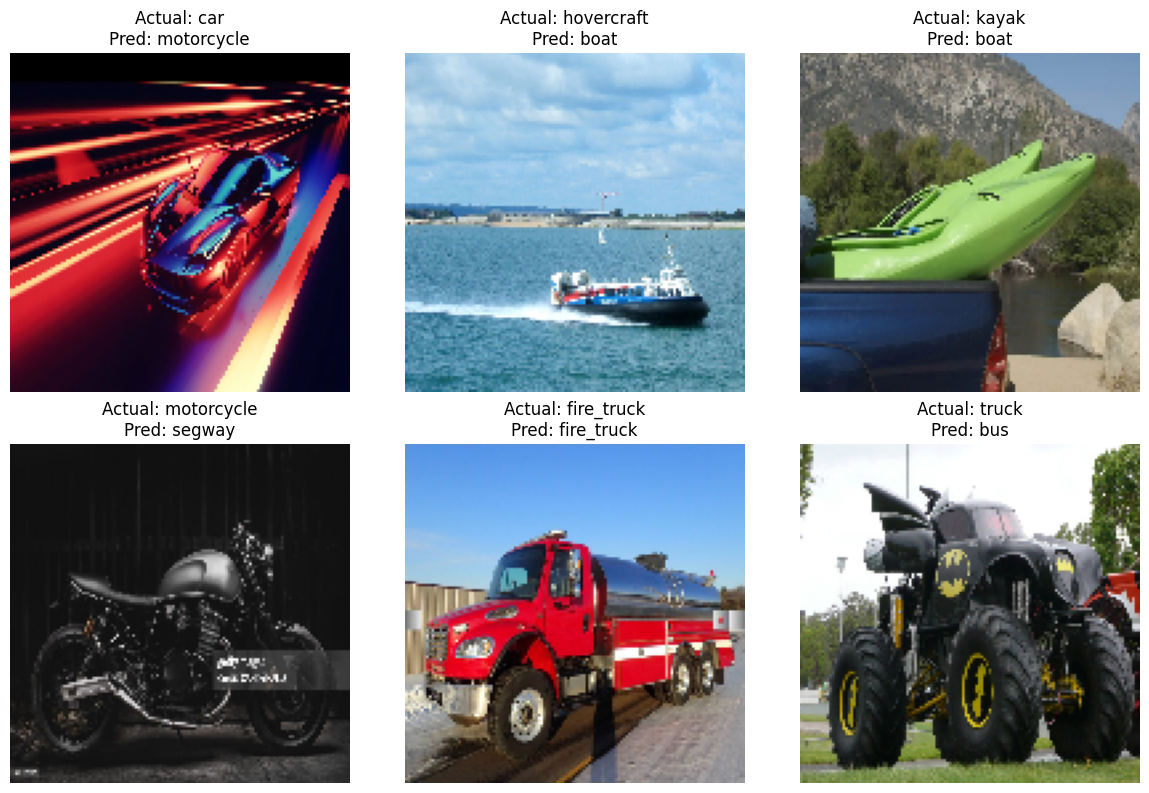

In [15]:
plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[i])
    plt.title(f"Actual: {categories[y_true[i]]}\nPred: {categories[y_pred_classes[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **A. Why OpenCV was used?**
OpenCV was used for image preprocessing tasks such as reading images (cv2.imread), resizing them to a fixed size, converting color format (BGR to RGB), and normalizing pixel values. It is efficient and optimized for handling large image datasets.

# **B. CNN Architecture Chosen**
A Sequential CNN model was used with:

- 3 Convolution layers (32, 64, 128 filters)
- MaxPooling layers for downsampling
- Flatten layer
- Fully connected Dense layer (256 neurons)
- Dropout layer to reduce overfitting
- Softmax output layer for multi-class classification

# **C. Preprocessing Steps**
- Image reading using OpenCV
- Resizing to 128×128
- BGR to RGB conversion
- Pixel normalization (0–1)

# **D. Challenges Faced**
- Variation in vehicle images (angles, lighting)
- Similar classes (car vs truck)
- Large dataset increases training time
- Risk of overfitting handled using dropout